In [4]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

mlflow.set_tracking_uri("sqlite:///mlruns.db")
mlflow.set_experiment("customer-support-intelligence")



<Experiment: artifact_location='/Users/gia/Desktop/rihal/support-ticket-triage/notebooks/mlruns/2', creation_time=1782213015415, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1782213015415, lifecycle_stage='active', name='customer-support-intelligence', tags={}, trace_location=None, workspace='default'>

## Load data

In [52]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")


X_train = train_df["customer_text_clean"].fillna("").astype(str)
X_val = val_df["customer_text_clean"].fillna("").astype(str)

y_train = train_df["sentiment"]
y_val = val_df["sentiment"]

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")

Train: (876412,)
Val: (187803,)


## Problem Statement

Given a customer tweet directed at a company support account, predict whether 
the sentiment is negative (unhappy customer) or non-negative (question/positive).

Why it matters:
- Companies receive thousands of tweets daily
- Automatically detecting unhappy customers helps prioritize the support queue
- Reduces manual triage effort

Target: sentiment (negative / non-negative)
Baseline: random guessing = 50%, majority class = 76.8%

#### Model 1 — Logistic Regression (Baseline)
Accuracy 0.879, F1 negative 0.771. High recall on negative class (0.87) — catches most unhappy customers.

In [44]:
with mlflow.start_run(run_name="logistic_regression"):
    
    max_features = 5000
    C = 1.0
    
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_features", max_features)
    mlflow.log_param("C", C)
    mlflow.log_param("class_weight", "balanced")
    
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=max_features)),
        ("clf", LogisticRegression(C=C, max_iter=1000,
                                   class_weight="balanced",
                                   random_state=42))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="weighted")
    f1_neg = f1_score(y_val, y_pred, pos_label="negative", average="binary")
    
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_weighted", f1)
    mlflow.log_metric("f1_negative", f1_neg)
    mlflow.sklearn.log_model(pipeline, "model")
    
    print(classification_report(y_val, y_pred))
    print(f"Accuracy: {acc:.3f}")
    print(f"F1 weighted: {f1:.3f}")
    print(f"F1 negative: {f1_neg:.3f}")

2026/06/23 22:25:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/23 22:25:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


              precision    recall  f1-score   support

    negative       0.69      0.87      0.77     43912
non-negative       0.96      0.88      0.92    143891

    accuracy                           0.88    187803
   macro avg       0.82      0.88      0.84    187803
weighted avg       0.89      0.88      0.88    187803

Accuracy: 0.879
F1 weighted: 0.884
F1 negative: 0.771


#### Model 2 — SGD Classifier
Accuracy 0.861, F1 negative 0.734. Faster to train but slightly worse than LR across all metrics. LR is the better choice.

In [45]:
from sklearn.linear_model import SGDClassifier

with mlflow.start_run(run_name="sgd_classifier"):
    
    mlflow.log_param("model", "SGDClassifier")
    mlflow.log_param("max_features", 5000)
    mlflow.log_param("loss", "hinge")
    mlflow.log_param("class_weight", "balanced")
    
    pipeline_sgd = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("clf", SGDClassifier(loss="hinge",
                              class_weight="balanced",
                              random_state=42,
                              n_jobs=-1))
    ])
    
    pipeline_sgd.fit(X_train, y_train)
    y_pred_sgd = pipeline_sgd.predict(X_val)
    
    acc_sgd = accuracy_score(y_val, y_pred_sgd)
    f1_sgd = f1_score(y_val, y_pred_sgd, average="weighted")
    f1_neg_sgd = f1_score(y_val, y_pred_sgd, pos_label="negative", average="binary")
    
    mlflow.log_metric("accuracy", acc_sgd)
    mlflow.log_metric("f1_weighted", f1_sgd)
    mlflow.log_metric("f1_negative", f1_neg_sgd)
    mlflow.sklearn.log_model(pipeline_sgd, "model")
    
    print(classification_report(y_val, y_pred_sgd))
    print(f"Accuracy: {acc_sgd:.3f}")
    print(f"F1 weighted: {f1_sgd:.3f}")
    print(f"F1 negative: {f1_neg_sgd:.3f}")

2026/06/23 22:29:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/23 22:29:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


              precision    recall  f1-score   support

    negative       0.66      0.82      0.73     43912
non-negative       0.94      0.87      0.91    143891

    accuracy                           0.86    187803
   macro avg       0.80      0.85      0.82    187803
weighted avg       0.88      0.86      0.87    187803

Accuracy: 0.861
F1 weighted: 0.866
F1 negative: 0.734


In [67]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/sentiment_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved ")

Model saved 


In [70]:
import pickle
import joblib
import os

# load existing pickle
with open("../models/sentiment_model.pkl", "rb") as f:
    model = pickle.load(f)

# save as joblib
os.makedirs("../models", exist_ok=True)
joblib.dump(model, "../models/sentiment_model.joblib")


['../models/sentiment_model.joblib']

## Task 2: Regression — Predicting Response Time

Given a customer tweet, predict how long (in minutes) it will take the company to reply.

Why it matters:
- Helps companies set realistic SLA expectations
- Identifies tweets likely to wait too long
- Target: response_time_log (log-transformed, capped at 500 mins)

In [53]:

X_train_reg = train_df["customer_text_clean"].fillna("").astype(str)
y_train_reg = train_df["response_time_log"]

X_val_reg = val_df["customer_text_clean"].fillna("").astype(str)
y_val_reg = val_df["response_time_log"]

print(f"Train: {X_train_reg.shape}")
print(f"Val: {X_val_reg.shape}")
print(f"\nTarget distribution:")
print(y_train_reg.describe())

Train: (876412,)
Val: (187803,)

Target distribution:
count    876412.000000
mean          3.361126
std           1.671669
min           0.016529
25%           1.974081
50%           3.097837
75%           4.683519
max           6.216606
Name: response_time_log, dtype: float64


In [58]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

with mlflow.start_run(run_name="ridge_regression_baseline"):
    
    max_features = 5000
    alpha = 1.0
    
    mlflow.log_param("model", "Ridge")
    mlflow.log_param("max_features", max_features)
    mlflow.log_param("alpha", alpha)
    mlflow.log_param("target", "response_time_log")
    
    pipeline_reg = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=max_features)),
        ("reg", Ridge(alpha=alpha))
    ])
    
    pipeline_reg.fit(X_train_reg, y_train_reg)
    y_pred_reg = pipeline_reg.predict(X_val_reg)
    
    mae = mean_absolute_error(y_val_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred_reg))
    r2 = r2_score(y_val_reg, y_pred_reg)
    
    y_pred_mins = np.expm1(y_pred_reg)
    y_true_mins = np.expm1(y_val_reg)
    mae_real = mean_absolute_error(y_true_mins, y_pred_mins)
    
    mlflow.log_metric("mae_log", mae)
    mlflow.log_metric("rmse_log", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae_minutes", mae_real)
    mlflow.sklearn.log_model(pipeline_reg, "model")
    
    print(f"MAE (log scale):  {mae:.3f}")
    print(f"RMSE (log scale): {rmse:.3f}")
    print(f"R2:               {r2:.3f}")
    print(f"MAE (real mins):  {mae_real:.1f} mins")

2026/06/24 09:09:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/24 09:11:16 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/s0/fvbyv15d1ylfzr9zcc37fbd40000gn/T/tmpdp_t3dgh/model/model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.9.0', 'skops==0.14.0']. Set logging level to DEBUG to see the full traceback. 
2026/06/24 09:11:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


MAE (log scale):  1.256
RMSE (log scale): 1.517
R2:               0.176
MAE (real mins):  89.6 mins


In [60]:
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack, csr_matrix

le = LabelEncoder()
train_df["company_encoded"] = le.fit_transform(train_df["company_name"].fillna("unknown"))
val_df["company_encoded"] = val_df["company_name"].fillna("unknown").map(
    lambda x: le.transform([x])[0] if x in le.classes_ else -1
)

with mlflow.start_run(run_name="ridge_regression_with_company"):
    
    mlflow.log_param("model", "Ridge")
    mlflow.log_param("features", "text + company + hour + is_weekend")
    mlflow.log_param("alpha", 1.0)
    
    X_train_rich = train_df[["customer_text_clean", "company_encoded", "hour", "is_weekend"]].copy()
    X_val_rich = val_df[["customer_text_clean", "company_encoded", "hour", "is_weekend"]].copy()
    X_train_rich["customer_text_clean"] = X_train_rich["customer_text_clean"].fillna("").astype(str)
    X_val_rich["customer_text_clean"] = X_val_rich["customer_text_clean"].fillna("").astype(str)
    
    tfidf = TfidfVectorizer(max_features=5000)
    X_train_text = tfidf.fit_transform(X_train_rich["customer_text_clean"])
    X_val_text = tfidf.transform(X_val_rich["customer_text_clean"])
    
    X_train_extra = csr_matrix(X_train_rich[["company_encoded", "hour", "is_weekend"]].values)
    X_val_extra = csr_matrix(X_val_rich[["company_encoded", "hour", "is_weekend"]].values)
    
    X_train_combined = hstack([X_train_text, X_train_extra])
    X_val_combined = hstack([X_val_text, X_val_extra])
    
    reg = Ridge(alpha=1.0)
    reg.fit(X_train_combined, y_train_reg)
    y_pred_rich = reg.predict(X_val_combined)
    
    mae = mean_absolute_error(y_val_reg, y_pred_rich)
    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred_rich))
    r2 = r2_score(y_val_reg, y_pred_rich)
    
    y_pred_mins = np.expm1(y_pred_rich)
    y_true_mins = np.expm1(y_val_reg)
    mae_real = mean_absolute_error(y_true_mins, y_pred_mins)
    
    mlflow.log_metric("mae_log", mae)
    mlflow.log_metric("rmse_log", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae_minutes", mae_real)
    
    print(f"MAE (log):       {mae:.3f}")
    print(f"RMSE (log):      {rmse:.3f}")
    print(f"R2:              {r2:.3f}")
    print(f"MAE (real mins): {mae_real:.1f} mins")

MAE (log):       1.251
RMSE (log):      1.511
R2:              0.182
MAE (real mins): 89.3 mins


### Ridge + One-Hot Company Encoding

Label encoding assigns arbitrary integers to companies — Ridge treats them as continuous numbers which is meaningless. One-hot encoding gives each company its own binary column so the model learns each company's response pattern independently.

In [62]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
train_company = ohe.fit_transform(train_df[["company_name"]].fillna("unknown"))
val_company = ohe.transform(val_df[["company_name"]].fillna("unknown"))

train_hour = csr_matrix(train_df[["hour", "is_weekend"]].values)
val_hour = csr_matrix(val_df[["hour", "is_weekend"]].values)

tfidf2 = TfidfVectorizer(max_features=5000)
X_train_text2 = tfidf2.fit_transform(train_df["customer_text_clean"].fillna("").astype(str))
X_val_text2 = tfidf2.transform(val_df["customer_text_clean"].fillna("").astype(str))

X_train_ohe = hstack([X_train_text2, train_company, train_hour])
X_val_ohe = hstack([X_val_text2, val_company, val_hour])

with mlflow.start_run(run_name="ridge_onehot_company"):
    
    mlflow.log_param("model", "Ridge")
    mlflow.log_param("features", "text + onehot_company + hour + is_weekend")
    mlflow.log_param("alpha", 1.0)
    
    reg2 = Ridge(alpha=1.0)
    reg2.fit(X_train_ohe, y_train_reg)
    y_pred_ohe = reg2.predict(X_val_ohe)
    
    mae = mean_absolute_error(y_val_reg, y_pred_ohe)
    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred_ohe))
    r2 = r2_score(y_val_reg, y_pred_ohe)
    mae_real = mean_absolute_error(np.expm1(y_val_reg), np.expm1(y_pred_ohe))
    
    mlflow.log_metric("mae_log", mae)
    mlflow.log_metric("rmse_log", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae_minutes", mae_real)
    
    print(f"MAE (log):       {mae:.3f}")
    print(f"RMSE (log):      {rmse:.3f}")
    print(f"R2:              {r2:.3f}")
    print(f"MAE (real mins): {mae_real:.1f} mins")

MAE (log):       0.993
RMSE (log):      1.245
R2:              0.445
MAE (real mins): 77.7 mins


In [68]:
import pickle

regression_artifacts = {
    "model": reg2,
    "tfidf": tfidf2,
    "ohe": ohe
}

with open("../models/regression_model.pkl", "wb") as f:
    pickle.dump(regression_artifacts, f)

print("Regression model saved ")

Regression model saved 


In [71]:
import pickle
import joblib

with open("../models/regression_model.pkl", "rb") as f:
    reg_model = pickle.load(f)

joblib.dump(reg_model, "../models/regression_model.joblib")
print("Converted ")

Converted 


## Regression Model Comparison

Ridge with text only gave R2=0.176 and MAE=89.6 mins — weak because tweet text alone doesn't predict response time well.

Adding label-encoded company barely helped (R2=0.182) because Ridge treated company IDs as continuous numbers which is meaningless.

One-hot encoding company identity jumped R2 to 0.445 and MAE to 77.7 mins — confirms the EDA finding that which company you contact matters more than what you say.

Winner: Ridge with one-hot company + hour + text features.

In [65]:
import json


company_medians = train_df.groupby("company_name")["response_time_capped"].median().to_dict()
with open("../data/processed/company_medians.json", "w") as f:
    json.dump(company_medians, f)

print("Saved")

Saved


In [66]:
overall_median = train_df["response_time_capped"].median()
print(f"Overall median: {overall_median:.1f} mins")

Overall median: 21.1 mins


## Task 3: Clustering — Discovering Complaint Topics

Given customer tweets, group them into natural complaint categories without labels.

Why it matters:
- Companies don't know what customers complain about most
- Clustering surfaces recurring issues automatically
- Helps prioritize product improvements and support resources

Approach: TF-IDF + KMeans
No labels needed — unsupervised learning

In [77]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


cluster_df = train_df[["customer_text_clean", "sentiment", "company_name"]].copy()
cluster_df = cluster_df[cluster_df["customer_text_clean"].str.strip() != ""].dropna()

print(f"Clustering on: {len(cluster_df):,} tweets")

Clustering on: 876,411 tweets


In [88]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stops = list(ENGLISH_STOP_WORDS) + [
    "just", "thanks", "thank", "hi", "hey", "ok", "got",
    "im", "dont", "like", "know", "going", "getting", "yes",
    "amp", "pls", "dm", "sent", "need", "help"
]

tfidf_cluster = TfidfVectorizer(
    max_features=3000,
    min_df=5,
    max_df=0.95,
    stop_words=custom_stops
)
X_cluster = tfidf_cluster.fit_transform(cluster_df["customer_text_clean"])
print(f"TF-IDF matrix: {X_cluster.shape}")

TF-IDF matrix: (876411, 3000)


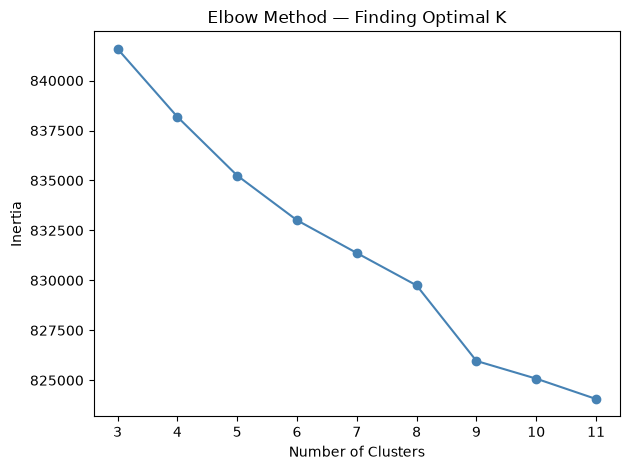

In [80]:
#find the best k 
#elbow way
inertias = []
K_range = range(3, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(K_range, inertias, marker="o", color="steelblue")
plt.title("Elbow Method — Finding Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [85]:
#Silhouette score
from sklearn.metrics import silhouette_score

sample_idx = np.random.choice(X_cluster.shape[0], 10000, replace=False)
X_sample = X_cluster[sample_idx]

scores = []
K_range = range(3, 12)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    scores.append(score)
    print(f"K={k}: silhouette={score:.3f}")

K=3: silhouette=0.011
K=4: silhouette=0.013
K=5: silhouette=0.013
K=6: silhouette=0.013
K=7: silhouette=0.014
K=8: silhouette=0.016
K=9: silhouette=0.016
K=10: silhouette=0.017
K=11: silhouette=0.017


In [83]:
n_clusters = 10

with mlflow.start_run(run_name="kmeans_clustering"):
    mlflow.log_param("model", "KMeans")
    mlflow.log_param("n_clusters", n_clusters)
    mlflow.log_param("max_features", 3000)
    mlflow.log_param("algorithm", "tfidf + kmeans")

    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    km.fit(X_cluster)

    cluster_df["cluster"] = km.labels_

    inertia = km.inertia_
    mlflow.log_metric("inertia", inertia)

    print(f"Inertia: {inertia:.0f}")
    print(f"\nCluster sizes:")
    print(cluster_df["cluster"].value_counts().sort_index())

Inertia: 825081

Cluster sizes:
cluster
0     11168
1     19472
2     37954
3    548920
4     15636
5     47597
6     83464
7     35814
8     33194
9     43192
Name: count, dtype: int64


In [84]:
feature_names = tfidf_cluster.get_feature_names_out()

print("Top words per cluster:\n")
for i in range(n_clusters):
    center = km.cluster_centers_[i]
    top_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    cluster_size = (cluster_df["cluster"] == i).sum()
    print(f"Cluster {i} ({cluster_size:,} tweets): {', '.join(top_words)}")

Top words per cluster:

Cluster 0 (11,168 tweets): waiting, im, minutes, ive, response, hour, delivery, flight, hours, reply
Cluster 1 (19,472 tweets): iphone, ios, update, 6s, new, battery, plus, phone, app, apple
Cluster 2 (37,954 tweets): help, need, account, hi, phone, pls, trying, just, hey, order
Cluster 3 (548,920 tweets): just, phone, flight, dont, like, fix, order, need, account, app
Cluster 4 (15,636 tweets): thank, great, ok, just, help, flight, appreciate, yes, dm, sent
Cluster 5 (47,597 tweets): im, trying, just, getting, going, having, phone, sure, dont, account
Cluster 6 (83,464 tweets): got, amp, want, going, internet, whats, just, dont, phone, ive
Cluster 7 (35,814 tweets): time, just, im, flight, dont, order, delivery, ive, phone, second
Cluster 8 (33,194 tweets): thanks, hi, just, flight, help, great, ok, reply, response, got
Cluster 9 (43,192 tweets): service, customer, worst, just, phone, poor, terrible, care, great, bad


#### KMeans on TF-IDF - Clustering Limitations

Silhouette scores: 0.011-0.017 (all very low — below 0.1 indicates weak cluster separation)

KMeans on TF-IDF is a weak baseline for short text:
- Tweets are too short for meaningful TF-IDF separation
- One cluster captures 63% of data — catch-all problem
- Silhouette never exceeds 0.02 regardless of K

Meaningful clusters found despite limitations:
- Cluster 0: Waiting/Response Time complaints
- Cluster 1: Apple/iOS Technical Issues
- Cluster 2: Account & Support Requests
- Cluster 4: Positive Interactions
- Cluster 9: Service Quality Complaints

Upgrade path: BERTopic with sentence transformers would resolve this —
semantic embeddings understand that "broken" and "not working" mean the same thing.

In [89]:
from sklearn.decomposition import LatentDirichletAllocation

with mlflow.start_run(run_name="lda_clustering"):
    mlflow.log_param("model", "LDA")
    mlflow.log_param("n_topics", 10)
    mlflow.log_param("max_features", 3000)

    lda = LatentDirichletAllocation(
        n_components=10,
        random_state=42,
        max_iter=10
    )
    lda.fit(X_cluster)

    feature_names = tfidf_cluster.get_feature_names_out()

    print("Top words per topic:\n")
    for i, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[-10:][::-1]
        top_words = [feature_names[j] for j in top_indices]
        print(f"Topic {i}: {', '.join(top_words)}")

Top words per topic:

Topic 0: iphone, update, ios, phone, new, battery, 11, updated, screen, fix
Topic 1: card, account, credit, email, change, booking, number, want, payment, details
Topic 2: fix, reply, response, question, check, shit, answer, really, support, guys
Topic 3: service, customer, worst, love, yall, good, time, phone, great, customers
Topic 4: order, delivery, delivered, amazon, package, today, refund, email, days, number
Topic 5: internet, network, outage, area, idea, service, speed, problem, data, le
Topic 6: game, xbox, store, code, amazon, issue, wells, fargo, online, bought
Topic 7: app, watch, tried, error, spotify, tv, working, music, work, account
Topic 8: que, la, el, en, ya, driver, lyft, mi, fuck, por
Topic 9: flight, train, delayed, time, london, hour, late, minutes, plane, trains


#### LDA Results — Much Better Than KMeans

LDA discovered 10 meaningful complaint topics:
- Delivery & food orders
- Account support requests  
- Billing & refunds
- Flight complaints
- Uber/driver issues
- UK train delays
- Internet outages
- iOS/app technical issues

LDA outperforms KMeans on short text because it models each tweet 
as a mixture of topics rather than forcing hard assignment to one cluster.

Winner: LDA with 10 topics

## Multilingual Pipeline 

Detecting and translating non-English tweets before clustering.
Sample of 50k to guarantee sufficient non-English representation.

In [5]:
multilingual_df = pd.read_csv("../data/processed/multilingual_sample.csv")
print(f"Loaded: {len(multilingual_df):,} tweets")
print(multilingual_df["language"].value_counts().head(8))

Loaded: 7,056 tweets
language
en    5000
es     538
fr     531
ja     396
pt     302
de     289
Name: count, dtype: int64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

custom_stops = list(ENGLISH_STOP_WORDS) + [
    "just", "thanks", "thank", "hi", "hey", "ok", "got",
    "im", "dont", "like", "know", "going", "getting", "yes",
    "amp", "pls", "dm", "sent", "need", "help"
]

tfidf_multi = TfidfVectorizer(max_features=3000, min_df=2, max_df=0.95, stop_words=custom_stops)
X_multi = tfidf_multi.fit_transform(multilingual_df["customer_text_clean"].fillna(""))

with mlflow.start_run(run_name="lda_multilingual_sample"):
    mlflow.log_param("model", "LDA")
    mlflow.log_param("n_topics", 10)
    mlflow.log_param("pipeline", "multilingual_translated")
    mlflow.log_param("sample_size", len(multilingual_df))

    lda_multi = LatentDirichletAllocation(n_components=10, random_state=42, max_iter=10)
    lda_multi.fit(X_multi)

    mlflow.sklearn.log_model(lda_multi, "lda_model")
    mlflow.log_metric("n_topics", 10)

    feature_names = tfidf_multi.get_feature_names_out()
    print("Topics after translation:\n")
    for i, topic in enumerate(lda_multi.components_):
        top_indices = topic.argsort()[-10:][::-1]
        top_words = [feature_names[j] for j in top_indices]
        print(f"Topic {i}: {', '.join(top_words)}")

2026/06/25 15:25:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/25 15:28:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/06/25 15:33:44 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Topics after translation:

Topic 0: arrived, amazon, delivery, order, today, prime, number, book, package, pm
Topic 1: received, amazon, email, good, havent, love, payment, ordered, package, delivered
Topic 2: question, __email__, quick, dmd, extra, nope, explain, come, does, real
Topic 3: fuck, account, available, think, paid, change, app, game, month, season
Topic 4: update, iphone, ios, phone, order, reply, problem, error, battery, solution
Topic 5: amazon, prime, want, service, tomorrow, watch, time, member, arrive, send
Topic 6: contact, kindness, mobile_care, tell, working, logistics, packages, home, carrier, amazon
Topic 7: response, hello, check, did, lol, mobile_carexi, connect, nice, good, understand
Topic 8: waiting, friday, black, delivery, things, amazon, wtf, answer, arrived, does
Topic 9: price, amazon, order, email, account, didnt, company, list, morning, following


#### Multilingual Clustering — Before vs After Translation

**Before (876k English only):**
- Topic 0: iOS/iPhone Issues
- Topic 1: Billing & Account
- Topic 2: Support Response Quality
- Topic 3: Service Complaints
- Topic 4: Delivery & Orders
- Topic 5: Internet & Network
- Topic 6: Gaming & Online Shopping
- Topic 7: App & Streaming
- Topic 8: Non-English / Rideshare (polluted — Spanish words)
- Topic 9: Travel Delays

**After (5k English + 2k translated):**
- Topic 0: Amazon Delivery & Orders
- Topic 1: Amazon Package & Email
- Topic 2: Unclear/Noise
- Topic 3: Account & Gaming
- Topic 4: iOS/iPhone Issues
- Topic 5: Amazon Prime & Streaming
- Topic 6: Logistics & Carriers
- Topic 7: Support Response
- Topic 8: Delivery Complaints
- Topic 9: Amazon Pricing & Orders

**Conclusion:** Small unbalanced sample (Amazon-heavy) produced weaker topics. Original LDA on 876k tweets is the stronger result. Key win: no foreign language pollution in any topic after translation.